Funathon

In [ ]:
uv sync

In [34]:
import mlflow
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [ ]:
import polars as pl

df = pl.read_parquet("https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet")

print(df.head())
print(f"Total rows: {len(df)}")

In [36]:
n_classes = df['code'].n_unique()
print(f"Number of unique NACE codes: {n_classes}")

Number of unique NACE codes: 311


In [37]:
from sklearn.model_selection import train_test_split

train_df, tmp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df  = train_test_split(tmp_df, test_size=0.50, random_state=42)

X_train, y_train = train_df["label"].to_numpy(), train_df["code"].to_numpy()
X_val, y_val = val_df["label"].to_numpy(), val_df["code"].to_numpy()
X_test, y_test = test_df["label"].to_numpy(), test_df["code"].to_numpy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 49000 | Val: 10500 | Test: 10500


In [38]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(train_df['code'].to_numpy())

LabelEncoder()

In [39]:
all_codes  = set(df['code'])
train_codes = set(train_df['code'])
missing = all_codes - train_codes

if missing:
    print(f"WARNING: {len(missing)} code(s) missing from training set: {missing}")
else:
    print(f"OK — all {len(all_codes)} codes appear in the training set.")

OK — all 311 codes appear in the training set.


In [ ]:
%pip install git+https://github.com/InseeFrLab/torchTextClassifiers.git

In [41]:
from torchTextClassifiers.value_encoder import ValueEncoder

value_encoder = ValueEncoder(label_encoder=encoder)

In [ ]:
!pip install tokenizers transformers

In [43]:

import sys
import traceback

print("Python:", sys.executable)
print()

try:
    from tokenizers import Tokenizer
    print("tokenizers import: OK")
except Exception:
    print("tokenizers import: FAILED")
    traceback.print_exc()

print()

try:
    from transformers import AutoTokenizer, PreTrainedTokenizerFast
    print("transformers import: OK")
except Exception:
    print("transformers import: FAILED")
    traceback.print_exc()


Python: /opt/python/bin/python

tokenizers import: OK

transformers import: OK


In [44]:

import sys

for module_name in list(sys.modules):
    if module_name == "torchTextClassifiers.tokenizers" or module_name.startswith(
        "torchTextClassifiers.tokenizers."
    ):
        del sys.modules[module_name]

from torchTextClassifiers.tokenizers import HAS_HF, WordPieceTokenizer

print("HAS_HF:", HAS_HF)

tokenizer = WordPieceTokenizer(vocab_size=5000, output_dim=10)
tokenizer.train(X_train)



from torchTextClassifiers.tokenizers import WordPieceTokenizer

tokenizer = WordPieceTokenizer(vocab_size=5000, output_dim=10)
tokenizer.train(X_train)




HAS_HF: True








In [45]:
from torchTextClassifiers.tokenizers import WordPieceTokenizer

tokenizer = WordPieceTokenizer(vocab_size=5000, output_dim=10)
tokenizer.train(X_train)

print("Output tensor size:", tokenizer.tokenize(X_train[0]).input_ids.shape)
print("Vocabulary size:", tokenizer.vocab_size)

# Look at an example of tokenization
print("Raw text", X_train[0])
print(
    "Tokens id:",
    tokenizer.tokenize(X_train[0]).input_ids.squeeze(0)
)
print(
    "Tokens:",
    tokenizer.tokenizer.convert_ids_to_tokens(
        tokenizer.tokenize(X_train[0]).input_ids.squeeze(0)
    )
)




Output tensor size: torch.Size([1, 10])
Vocabulary size: 5000
Raw text Real estate portfolio management
Tokens id: tensor([  3, 190, 206, 317, 137,   2,   1,   1,   1,   1])
Tokens: ['[SEP]', 'real', 'estate', 'portfolio', 'management', '[CLS]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [46]:
from torchTextClassifiers import ModelConfig, TrainingConfig, torchTextClassifiers

embedding_dim = 96

model_config = ModelConfig(
    embedding_dim=embedding_dim,
    num_classes=n_classes,)

ttc = torchTextClassifiers(
    tokenizer=tokenizer,
    model_config=model_config,
    value_encoder=value_encoder,
)

2026-05-28 08:19:13 - torchTextClassifiers.model.model - 🔹 No categorical variable network provided; using only text embeddings.


In [47]:
training_config = TrainingConfig(
    num_epochs=1,
    batch_size=128,
    lr=5 * 1e-4,
    patience_early_stopping=5,
)

In [ ]:
mlflow.set_experiment("funathon-2026-project2")
mlflow.pytorch.autolog()

with mlflow.start_run() as run:
    # This should take approximately 1-2mn
    ttc.train(
        X_train,
        y_train,
        training_config=training_config,
        X_val=X_val,
        y_val=y_val,
        verbose=True,
    )

    mlflow.log_artifacts(
        training_config.save_path,   # local folder produced by ttc.train()
        artifact_path="model_artifacts",
    )

In [ ]:
import s3fs

fs = s3fs.S3FileSystem(
    anon=True,  # public bucket
    endpoint_url="https://minio.lab.sspcloud.fr",
)

local_dir = "./mlflow-artifacts/"
fs.get(
    "projet-funathon/diffusion/mlflow-artifacts/",
    local_dir,
    recursive=True,
)
# Rebuild the torchTextClassifiers object from the downloaded files
ttc = torchTextClassifiers.load(local_dir)

ttc.pytorch_model.eval()

In [ ]:
pip install captum

In [ ]:
import sys
import captum
from captum.attr import LayerIntegratedGradients

print("Python:", sys.executable)
print("Captum version:", captum.__version__)
print("Captum imported successfully.")

import importlib
from captum.attr import LayerIntegratedGradients

# Reload the specific module where HAS_CAPTUM is defined
ttc_module = importlib.import_module(
    "torchTextClassifiers.torchTextClassifiers"
)

print("Before reload:", ttc_module.HAS_CAPTUM)

importlib.reload(ttc_module)

print("After reload:", ttc_module.HAS_CAPTUM)


In [ ]:
import random

random_indices = random.sample(range(len(X_test)), 3)
example_texts = X_test[random_indices]
example_true_codes = y_test[random_indices]
print(example_texts)
top_k = 5
results = ttc.predict(example_texts, top_k=top_k, explain_with_captum=True)
for i, text in enumerate(example_texts):
    predicted_codes = [results["prediction"][i][k] for k in range(top_k)]
    confidence = [results["confidence"][i][k].item() for k in range(top_k)]
    print(f"\nText: {text}")
    print(f"  True code: {example_true_codes[i]}")
    for code, conf in zip(predicted_codes, confidence):
        print(f"  {code}  (confidence: {conf:.3f})")

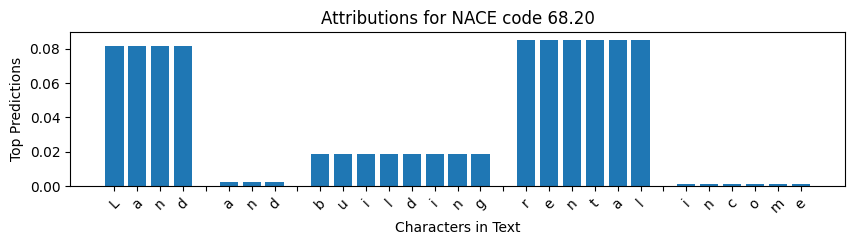

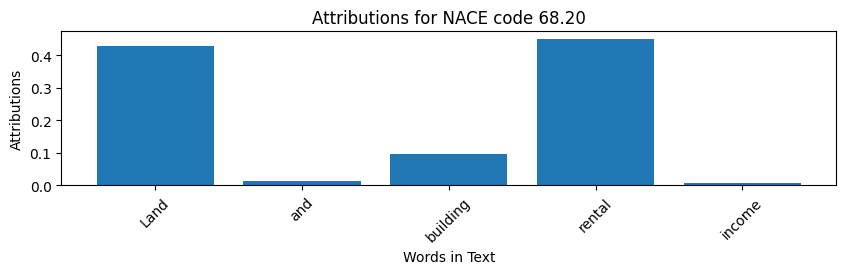

In [56]:
from torchTextClassifiers.utilities.plot_explainability import (
    map_attributions_to_char, map_attributions_to_word,
    plot_attributions_at_char, plot_attributions_at_word, figshow,
)

text_idx = 0
top_k_idx = 0
text_sample         = example_texts[text_idx]
offsets             = results["offset_mapping"][text_idx]
word_ids            = results["word_ids"][text_idx]
predicted_code = results["prediction"][text_idx][top_k_idx]

attributions  = results["captum_attributions"][text_idx][top_k_idx] # (seq_len,)

words, word_attributions = map_attributions_to_word(
    attributions.unsqueeze(0), text_sample, word_ids, offsets
)
char_attributions = map_attributions_to_char(attributions.unsqueeze(0), offsets, text_sample)

titles = [f"Attributions for NACE code {predicted_code}"]

figshow(plot_attributions_at_char(
    text=text_sample, attributions_per_char=char_attributions, titles=titles,
)[0])

figshow(plot_attributions_at_word(
    text=text_sample, words=words.values(), attributions_per_word=word_attributions, titles=titles,
)[0])

In [57]:
results_test = ttc.predict(X_test, top_k=1)
preds    = results_test["prediction"].squeeze(1)
accuracy = (preds == y_test).mean()
print(f"Test accuracy: {accuracy:.4f} ({int(accuracy * len(y_test))}/{len(y_test)} correct)")

Test accuracy: 0.8735 (9172/10500 correct)
